# GSB 5544 — PA 3.1: Concatenating, Joining, and Pivoting Data — SOLUTION

There are several ways of answering many questions in this notebook, but try to use the new operations (concatenate, joint/merge, pivot) whenever possible to get practice.

In [1]:
import pandas as pd

## Movie Ratings Data

The Movielens data set (https://dlsun.github.io/pods/data/ml-1m/ ) contains 1 million movie ratings submitted by users. The information about the movies, ratings, and users are stored in three separate files, called `movies.dat`, `ratings.dat`, and `users.dat`. The column names are not included with the data files. Refer to the webpage above for more information.


1\. Read in each of the data files.


(Hint: see the note in the documentation about the delimiter; use the `sep` argument in `read_csv`. If you get an error when reading the `movies.dat` file, try `encoding_errors = "ignore"` in `read_csv`.)

The README says fields are separated by `::`. A multi-character separator needs `engine="python"`, and because the files have no header row we pass `header=None` and supply `names=` ourselves (column names taken from the README). `movies.dat` contains a few non-UTF-8 bytes in titles, hence `encoding_errors="ignore"`.

In [2]:
base = "https://dlsun.github.io/pods/data/ml-1m/"

movies  = pd.read_csv(base + "movies.dat",  sep="::", engine="python", header=None,
                      names=["MovieID", "Title", "Genres"], encoding_errors="ignore")
ratings = pd.read_csv(base + "ratings.dat", sep="::", engine="python", header=None,
                      names=["UserID", "MovieID", "Rating", "Timestamp"])
users   = pd.read_csv(base + "users.dat",   sep="::", engine="python", header=None,
                      names=["UserID", "Gender", "Age", "Occupation", "Zip"])

print(movies.shape, ratings.shape, users.shape)

(3883, 3) (1000209, 4) (6040, 5)


In [3]:
movies.head()

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [5]:
users.head()

,UserID,Gender,Age,Occupation,Zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


2\. Which age group tends to give the highest ratings? Create an appropriate summary to answer this question.

(Note the way age is coded in the [REAMDE file](https://dlsun.github.io/pods/data/ml-1m/README.txt).)

The rating and the rater's age live in different tables, so join `ratings` to `users` on `UserID`. Every rating has exactly one user (`validate="many_to_one"`). `Age` is a *code* (1, 18, 25, …) for an age range — map it to the README's labels before summarizing.

In [6]:
age_labels = {1: "Under 18", 18: "18-24", 25: "25-34", 35: "35-44", 45: "45-49", 50: "50-55", 56: "56+"}

ratings_users = ratings.merge(users, on="UserID", how="left", validate="many_to_one")
ratings_users["AgeGroup"] = ratings_users["Age"].map(age_labels)

by_age = (ratings_users.groupby("AgeGroup")["Rating"]
                       .agg(n_ratings="size", mean_rating="mean")
                       .sort_values("mean_rating", ascending=False)
                       .round(3))
by_age

,n_ratings,mean_rating
AgeGroup,,
56+,38780,3.767
50-55,72490,3.715
45-49,83633,3.638
35-44,199003,3.618
Under 18,27211,3.550
25-34,395556,3.545
18-24,183536,3.508


**Answer:** Average ratings rise steadily with age. The **56+** group is the most generous (mean about 3.77) and **18–24** the harshest (about 3.51), with every group in between falling in order. The differences are small in absolute terms, but with tens of thousands of ratings per group they are very stable.

3\. Among movies with at least 100 ratings, which movies had the highest average rating? The lowest?

Summarize `ratings` to one row per movie (count and mean), then join the titles on — a lookup join, one movie per `MovieID`. Filter to 100+ ratings *after* counting.

In [7]:
movie_stats = (ratings.groupby("MovieID")["Rating"]
                      .agg(n_ratings="size", avg_rating="mean")
                      .reset_index()
                      .merge(movies, on="MovieID", how="left", validate="one_to_one"))

popular = movie_stats[movie_stats["n_ratings"] >= 100]
popular.sort_values("avg_rating", ascending=False)[["Title", "n_ratings", "avg_rating"]].head(10)

,Title,n_ratings,avg_rating
1839,Seven Samurai (The Magnificent Seven) (Shichin...,628,4.560510
309,"Shawshank Redemption, The (1994)",2227,4.554558
802,"Godfather, The (1972)",2223,4.524966
708,"Close Shave, A (1995)",657,4.520548
49,"Usual Suspects, The (1995)",1783,4.517106
513,Schindler's List (1993),2304,4.510417
1066,"Wrong Trousers, The (1993)",882,4.507937
861,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),470,4.491489
1108,Raiders of the Lost Ark (1981),2514,4.477725
843,Rear Window (1954),1050,4.476190


In [8]:
popular.sort_values("avg_rating")[["Title", "n_ratings", "avg_rating"]].head(10)

,Title,n_ratings,avg_rating
764,Kazaam (1996),120,1.466667
3353,Battlefield Earth (2000),342,1.611111
3556,Pokmon the Movie 2000 (2000),100,1.620000
2612,Aces: Iron Eagle III (1992),125,1.640000
2190,Police Academy 6: City Under Siege (1989),149,1.657718
2359,Baby Geniuses (1999),164,1.701220
2189,Police Academy 5: Assignment: Miami Beach (1988),150,1.766667
1818,Exorcist II: The Heretic (1977),113,1.769912
3044,Stop! Or My Mom Will Shoot (1992),179,1.782123
3327,"Flintstones in Viva Rock Vegas, The (2000)",128,1.804688


**Answer:** Highest: *Seven Samurai* (4.56), *The Shawshank Redemption* (4.55), *The Godfather* (4.52), *A Close Shave* (4.52), *The Usual Suspects* (4.52). Lowest: *Kazaam* (1.47), *Battlefield Earth* (1.61), *Pokémon the Movie 2000* (1.62), *Aces: Iron Eagle III* (1.64), *Police Academy 6* (1.66). The 100-rating floor matters: without it the extremes are movies rated once or twice.

4\. For each movie, calculate the average rating and the proportion of the ratings that were from users aged 18-24. Make a scatterplot showing the relationship between the average rating and the 18-24 share, with each point representing a movie. (Optional: Use the size of each point to represent the number of users who rated the movie.)

Reuse `ratings_users` (ratings joined to users). A 0/1 indicator for "rater is 18–24" has a mean equal to the *share* of such raters, so one `groupby().agg()` gives the average rating, the 18–24 share, and the count per movie. Join the titles on afterwards.

In [9]:
ratings_users["is_18_24"] = (ratings_users["Age"] == 18).astype(int)

by_movie = (ratings_users.groupby("MovieID")
                         .agg(avg_rating=("Rating", "mean"),
                              share_18_24=("is_18_24", "mean"),
                              n_ratings=("Rating", "size"))
                         .reset_index()
                         .merge(movies, on="MovieID", how="left", validate="one_to_one"))
by_movie.head()

,MovieID,avg_rating,share_18_24,n_ratings,Title,Genres
0,1,4.146846,0.215696,2077,Toy Story (1995),Animation|Children's|Comedy
1,2,3.201141,0.219686,701,Jumanji (1995),Adventure|Children's|Fantasy
2,3,3.016736,0.223849,478,Grumpier Old Men (1995),Comedy|Romance
3,4,2.729412,0.229412,170,Waiting to Exhale (1995),Comedy|Drama
4,5,3.006757,0.219595,296,Father of the Bride Part II (1995),Comedy


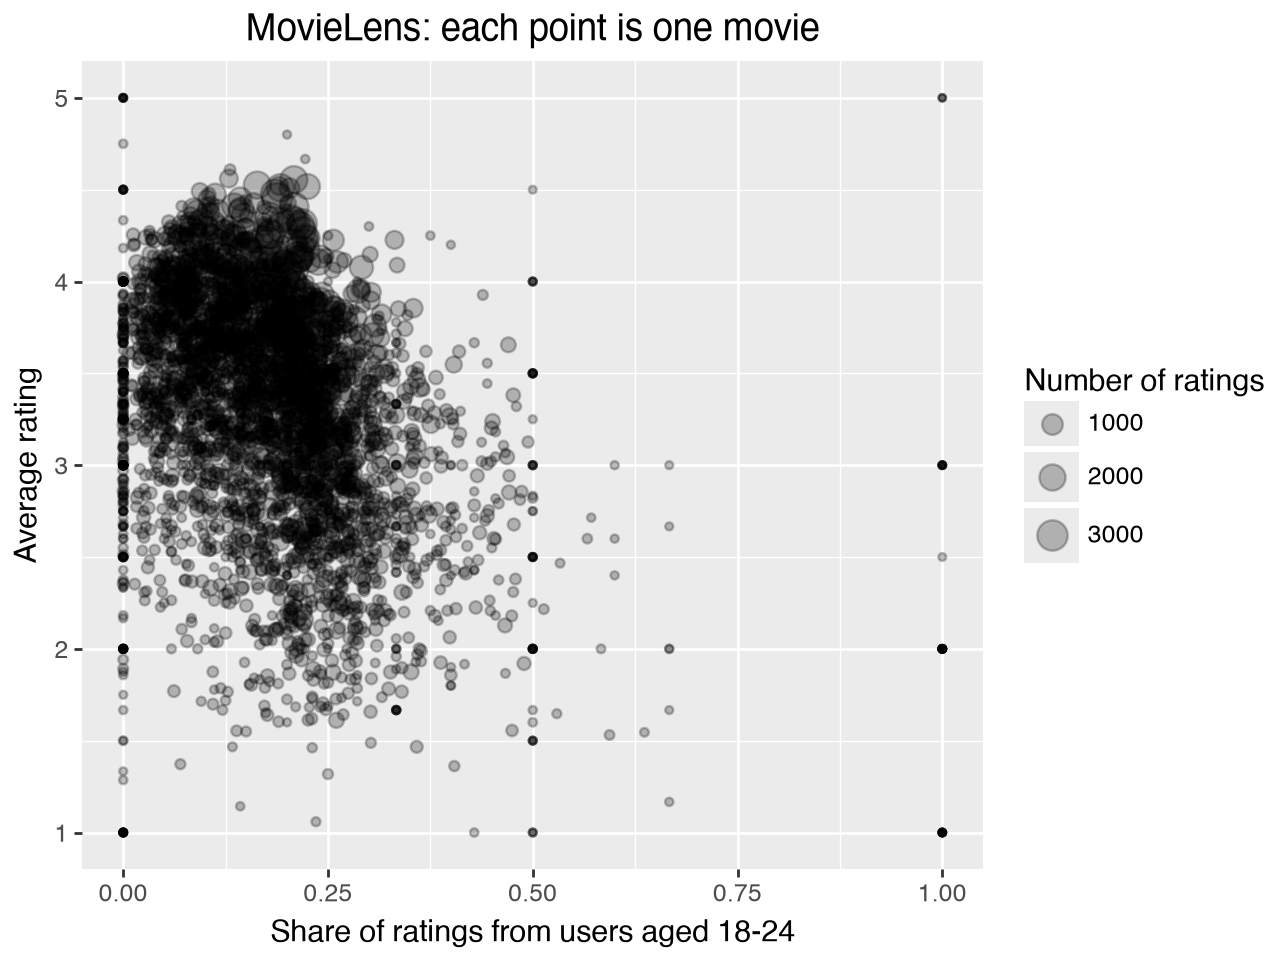

In [10]:
from plotnine import *

(ggplot(by_movie, aes(x="share_18_24", y="avg_rating", size="n_ratings"))
 + geom_point(alpha=0.25)
 + labs(x="Share of ratings from users aged 18-24", y="Average rating",
        size="Number of ratings", title="MovieLens: each point is one movie")
)

In [11]:
by_movie[["avg_rating", "share_18_24"]].corr().round(3)

,avg_rating,share_18_24
avg_rating,1.000,-0.353
share_18_24,-0.353,1.000


**Answer:** There is a moderate **negative** relationship (correlation about −0.35): movies whose audience skews 18–24 tend to have lower average ratings, consistent with part 2 (younger users rate more harshly, and they also gravitate to different films). Heavily-rated movies (big points) cluster at a 10–30% share with ratings of 3–4.5; the extreme shares (0% or 100%) are movies with a handful of ratings.

5\. Calculate the number of ratings by movie. How many of the movies had zero ratings?

(_Hint_: Why is an inner join not sufficient here?)

An inner join between `movies` and a per-movie count keeps only movies that *have* ratings — the zero-rating movies are exactly the rows an inner join throws away. A **left** join from `movies` keeps them, with `NaN` in the count column, which we then fill with 0.

In [12]:
counts = ratings.groupby("MovieID").size().rename("n_ratings").reset_index()

movie_counts = movies.merge(counts, on="MovieID", how="left", validate="one_to_one")
movie_counts["n_ratings"] = movie_counts["n_ratings"].fillna(0).astype(int)

print("movies in movies.dat:", len(movies))
print("movies with ratings :", len(movies.merge(counts, on="MovieID", how="inner")))
print("movies with zero    :", (movie_counts["n_ratings"] == 0).sum())

movies in movies.dat: 3883
movies with ratings : 3706
movies with zero    : 177


In [13]:
movie_counts[movie_counts["n_ratings"] == 0].head(10)

,MovieID,Title,Genres,n_ratings
50,51,Guardian Angel (1994),Action|Drama|Thriller,0
107,109,Headless Body in Topless Bar (1995),Comedy,0
113,115,Happiness Is in the Field (1995),Comedy,0
141,143,Gospa (1995),Drama,0
281,284,New York Cop (1996),Action|Crime,0
282,285,Beyond Bedlam (1993),Drama|Horror,0
391,395,Desert Winds (1995),Drama,0
395,399,Girl in the Cadillac (1995),Drama,0
396,400,Homage (1995),Drama,0
399,403,Two Crimes (1995),Comedy|Crime|Drama,0


**Answer:** 3,883 movies are listed but only 3,706 were rated, so **177 movies have zero ratings**. An inner join returns 3,706 rows and never shows the missing 177; the left join keeps every movie and reveals them as `NaN` counts (filled with 0). The `_merge` indicator or a left anti join (`movies[~movies["MovieID"].isin(ratings["MovieID"])]`) gives the same 177.

6\. How many movies received both a 1 and a 5 rating? Which movies? How many ratings of each type (1 or 5 stars)? Answer these question by joining two appropriate tables.

Build two small tables — the number of 1-star ratings per movie and the number of 5-star ratings per movie — and **inner join** them: a movie appears in the result only if it is in both, i.e. it received both a 1 and a 5. The joined columns answer "how many of each type".

In [14]:
ones  = ratings[ratings["Rating"] == 1].groupby("MovieID").size().rename("n_1").reset_index()
fives = ratings[ratings["Rating"] == 5].groupby("MovieID").size().rename("n_5").reset_index()

both = (ones.merge(fives, on="MovieID", how="inner", validate="one_to_one")
            .merge(movies, on="MovieID", how="left", validate="one_to_one"))

print("movies with both a 1 and a 5:", len(both))
both.sort_values("n_1", ascending=False)[["Title", "n_1", "n_5"]].head(10)

movies with both a 1 and a 5: 2986


,Title,n_1,n_5
2022,Wild Wild West (1999),314,16
2700,Battlefield Earth (2000),221,3
2029,"Blair Witch Project, The (1999)",219,180
1136,Batman & Robin (1997),191,17
2515,Mission to Mars (2000),169,32
444,Super Mario Bros. (1993),165,11
1029,Mars Attacks! (1996),163,84
1825,Howard the Duck (1986),162,9
124,Congo (1995),154,11
1971,Superman IV: The Quest for Peace (1987),149,7


In [15]:
# The most polarizing: many 1s AND many 5s
both["min_count"] = both[["n_1", "n_5"]].min(axis=1)
both.sort_values("min_count", ascending=False)[["Title", "n_1", "n_5"]].head(10)

,Title,n_1,n_5
2029,"Blair Witch Project, The (1999)",219,180
1985,"Rocky Horror Picture Show, The (1975)",145,239
1958,Star Wars: Episode I - The Phantom Menace (1999),143,400
1225,Starship Troopers (1997),139,152
1369,Armageddon (1998),127,153
1145,Face/Off (1997),110,233
2723,Mission: Impossible 2 (2000),110,143
229,Natural Born Killers (1994),110,119
2031,Eyes Wide Shut (1999),110,160
2009,Austin Powers: The Spy Who Shagged Me (1999),108,256


In [16]:
# Same answer by pivoting instead of joining: one row per movie, one column per star rating
star_counts = pd.crosstab(ratings["MovieID"], ratings["Rating"])
((star_counts[1] > 0) & (star_counts[5] > 0)).sum()

np.int64(2986)

**Answer:** **2,986 movies** received at least one 1-star *and* at least one 5-star rating (out of 3,706 rated movies). The `n_1` and `n_5` columns give the number of each; for example *Wild Wild West* has 314 ones and 16 fives, while *The Blair Witch Project* is genuinely polarizing with 219 ones and 180 fives. A crosstab of `MovieID` by `Rating` (a pivot) reaches the same 2,986 without a join.